# H3 — Sensibilité au bruit de labels

## Hypothèse
> *Les méthodes de suréchantillonnage comme SMOTE sont plus sensibles au bruit de labels, entraînant une dégradation de la PR-AUC supérieure à 15%, tandis que les méthodes adaptatives ou hybrides (ADASYN, SMOTE+Tomek) présentent une meilleure robustesse (dégradation ≤ 8%).*

## Extension du protocole
- **Bruit progressif** : 0%, 5%, 10%, 15%, 20% (au lieu de seulement 10%)
- **Bruit asymétrique** : uniquement sur la classe majoritaire (plus réaliste)
- **Bruit symétrique** : original (les deux classes affectées)
- **Visualisation** : courbes de dégradation en fonction du niveau de bruit

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',

    'axes.labelcolor': 'black',
    'axes.titlecolor': 'black',
    'text.color': 'black',

    'xtick.color': 'black',
    'ytick.color': 'black',

    'grid.color': 'gray',
    'grid.linestyle': '--',
    'grid.alpha': 0.3,

    'font.family': 'sans-serif',  # better for papers
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

COLORS = {
    'SMOTE'       : '#4e9af1',
    'ADASYN'      : '#f1614e',
    'SMOTE+Tomek' : '#f1a94e',
    'RF_base'     : '#888888',
}
MARKERS = {'SMOTE': 'o', 'ADASYN': 's', 'SMOTE+Tomek': '^', 'RF_base': 'D'}
print("✓ Prêt")

✓ Prêt


In [2]:
# ============================================================
# CHARGEMENT ET CONSTRUCTION DU DÉSÉQUILIBRE 1:50
# ============================================================
df = pd.read_csv("D:\\ENSET\\S2\\Méthodologie de Recherche\\Datasets\\creditcard.csv")
df = df.dropna(axis=1, how='all')
X_full = df.drop(['Class'], axis=1).values
y_full = df['Class'].values

rng = np.random.RandomState(42)
idx_fraud  = np.where(y_full == 1)[0]
idx_normal = np.where(y_full == 0)[0]

n_fraud = len(idx_fraud)             # 492
idx_normal_sub = rng.choice(idx_normal, size=n_fraud * 50, replace=False)
indices = np.concatenate([idx_fraud, idx_normal_sub])
rng.shuffle(indices)
X = X_full[indices]
y = y_full[indices]

print(f"Dataset : Normal={(y==0).sum():,} | Fraude={(y==1).sum()} | Ratio 1:{round((y==0).sum()/(y==1).sum())}")

Dataset : Normal=24,600 | Fraude=492 | Ratio 1:50


In [3]:
# ============================================================
# FONCTIONS DE BRUIT
# ============================================================

def add_noise_symmetric(y, ratio=0.10, seed=42):
    """
    Bruit SYMÉTRIQUE : on inverse aléatoirement `ratio` % des labels,
    indépendamment de la classe d'origine.

    Problème : avec ratio=0.10 sur un dataset 1:50, ~2 450 normaux
    sont transformés en fraudes, créant une classe minoritaire
    artificiellement gonflée. Ce bruit est peu réaliste.
    """
    rng = np.random.RandomState(seed)
    y_noisy = y.copy()
    n = int(len(y) * ratio)
    idx = rng.choice(len(y), n, replace=False)
    y_noisy[idx] = 1 - y_noisy[idx]
    return y_noisy


def add_noise_asymmetric(y, ratio=0.10, seed=42):
    """
    Bruit ASYMÉTRIQUE : on inverse uniquement `ratio` % des labels
    de la classe MAJORITAIRE (normaux → fraudes).

    Plus réaliste dans un contexte de fraude :
    → simule des fraudes non détectées lors de l'annotation,
      étiquetées par erreur comme normales.
    → la classe minoritaire originale reste intacte.
    """
    rng = np.random.RandomState(seed)
    y_noisy = y.copy()
    idx_majority = np.where(y == 0)[0]  # uniquement les normaux
    n = int(len(idx_majority) * ratio)
    idx = rng.choice(idx_majority, n, replace=False)
    y_noisy[idx] = 1  # normal → fraude (faux négatif d'annotation)
    return y_noisy


print("✓ Fonctions de bruit définies (symétrique + asymétrique)")

✓ Fonctions de bruit définies (symétrique + asymétrique)


In [4]:
# ============================================================
# FONCTION D'ÉVALUATION
# ============================================================
# IMPORTANT : le bruit est appliqué UNIQUEMENT sur y_train.
# y_test reste TOUJOURS propre → on évalue sur la vraie distribution.
# Cela simule le scénario réel où :
#   - les données d'entraînement sont annotées avec erreurs,
#   - les données de test représentent la réalité.

def evaluate_with_noise(sampler, y_train_noisy_fn, noise_ratio):
    """
    Évalue la PR-AUC moyenne sur 5 plis avec bruit sur les labels d'entraînement.

    Le split est fait sur y_clean pour garantir la stratification.
    Ensuite, les labels d'entraînement sont bruités DANS la boucle.
    """
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    model = RandomForestClassifier(random_state=42)

    for fold_seed, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train = y[train_idx].copy()
        y_test  = y[test_idx]           # TOUJOURS propre

        # Bruit appliqué sur y_train uniquement
        y_train_noisy = y_train_noisy_fn(
            y_train, ratio=noise_ratio, seed=42 + fold_seed
        )

        imp = SimpleImputer(strategy='mean')
        X_train = imp.fit_transform(X_train)
        X_test  = imp.transform(X_test)

        sc = StandardScaler()
        X_train = sc.fit_transform(X_train)
        X_test  = sc.transform(X_test)

        # Rééquilibrage sur les labels BRUITÉS
        try:
            X_res, y_res = sampler.fit_resample(X_train, y_train_noisy)
        except Exception:
            # ADASYN peut échouer si les voisins sont insuffisants
            X_res, y_res = X_train, y_train_noisy

        model.fit(X_res, y_res)
        y_prob = model.predict_proba(X_test)[:, 1]
        # Évaluation sur y_test PROPRE
        scores.append(average_precision_score(y_test, y_prob))

    return np.mean(scores)


print("✓ Fonction d'évaluation avec bruit définie")

✓ Fonction d'évaluation avec bruit définie


In [5]:
# ============================================================
# EXPÉRIENCE H3 — Niveaux de bruit progressifs
# ============================================================
# On teste 5 niveaux de bruit : 0%, 5%, 10%, 15%, 20%
# pour chaque méthode, avec les deux types de bruit.
# Cela permet de tracer une courbe de dégradation complète
# au lieu d'un seul point à 10%.

noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20]
methods = {
    'SMOTE'       : SMOTE(random_state=42),
    'ADASYN'      : ADASYN(random_state=42),
    'SMOTE+Tomek' : SMOTETomek(random_state=42),
}

# Stockage des résultats
results_sym   = {name: [] for name in methods}  # bruit symétrique
results_asym  = {name: [] for name in methods}  # bruit asymétrique
results_sym['RF_base']  = []
results_asym['RF_base'] = []

print(f"Calcul sur {len(noise_levels)} niveaux de bruit × {len(methods)} méthodes × 2 types...")
print(f"(Patience, cela peut prendre quelques minutes)")
print()

for noise in noise_levels:
    print(f"Bruit {noise*100:.0f}%...", end=' ')

    # Baseline RF sans rééquilibrage
    results_sym['RF_base'].append(
        evaluate_with_noise(None, add_noise_symmetric, noise)
        if noise > 0 else
        # Pour noise=0, la fonction de bruit ne change rien
        evaluate_with_noise(None, add_noise_symmetric, 0.0)
    )
    results_asym['RF_base'].append(
        evaluate_with_noise(None, add_noise_asymmetric, noise)
    )

    for name, sampler in methods.items():
        results_sym[name].append(
            evaluate_with_noise(sampler, add_noise_symmetric, noise)
        )
        results_asym[name].append(
            evaluate_with_noise(sampler, add_noise_asymmetric, noise)
        )

    print("OK")

# Convertir en arrays
for d in [results_sym, results_asym]:
    for k in d:
        d[k] = np.array(d[k])

print("\n✓ Calcul terminé")

Calcul sur 5 niveaux de bruit × 3 méthodes × 2 types...
(Patience, cela peut prendre quelques minutes)

Bruit 0%... 

OK
Bruit 5%... OK
Bruit 10%... OK
Bruit 15%... OK
Bruit 20%... OK

✓ Calcul terminé


In [6]:
# ============================================================
# TABLEAU DE RÉSULTATS — Dégradation par méthode
# ============================================================
print("BRUIT SYMÉTRIQUE — PR-AUC et % de dégradation vs bruit=0")
print("=" * 70)
print(f"{'Méthode':<15}", end='')
for n in noise_levels:
    print(f"{'%3d%%'%int(n*100):>12}", end='')
print()
print("-" * 70)

for name, vals in results_sym.items():
    base = vals[0]  # PR-AUC à bruit=0%
    print(f"{name:<15}", end='')
    for i, v in enumerate(vals):
        if i == 0:
            print(f"{v:>8.4f}      ", end='')
        else:
            deg = (base - v) / base * 100
            print(f"{v:>6.4f}({deg:>+5.1f}%)", end='')
    print()

print()
print("BRUIT ASYMÉTRIQUE — PR-AUC et % de dégradation vs bruit=0")
print("=" * 70)
print(f"{'Méthode':<15}", end='')
for n in noise_levels:
    print(f"{'%3d%%'%int(n*100):>12}", end='')
print()
print("-" * 70)

for name, vals in results_asym.items():
    base = vals[0]
    print(f"{name:<15}", end='')
    for i, v in enumerate(vals):
        if i == 0:
            print(f"{v:>8.4f}      ", end='')
        else:
            deg = (base - v) / base * 100
            print(f"{v:>6.4f}({deg:>+5.1f}%)", end='')
    print()

BRUIT SYMÉTRIQUE — PR-AUC et % de dégradation vs bruit=0
Méthode                  0%          5%         10%         15%         20%
----------------------------------------------------------------------
SMOTE            0.9068      0.8106(+10.6%)0.7627(+15.9%)0.6872(+24.2%)0.6182(+31.8%)
ADASYN           0.9029      0.7800(+13.6%)0.7056(+21.8%)0.6159(+31.8%)0.5260(+41.7%)
SMOTE+Tomek      0.9068      0.8167( +9.9%)0.7597(+16.2%)0.6835(+24.6%)0.6251(+31.1%)
RF_base          0.8985      0.8760( +2.5%)0.8481( +5.6%)0.8189( +8.9%)0.7730(+14.0%)

BRUIT ASYMÉTRIQUE — PR-AUC et % de dégradation vs bruit=0
Méthode                  0%          5%         10%         15%         20%
----------------------------------------------------------------------
SMOTE            0.9068      0.8406( +7.3%)0.8274( +8.8%)0.8167( +9.9%)0.7983(+12.0%)
ADASYN           0.9029      0.8104(+10.2%)0.7906(+12.4%)0.7798(+13.6%)0.7714(+14.6%)
SMOTE+Tomek      0.9068      0.8461( +6.7%)0.8222( +9.3%)0.8120(+10.5%)0.8

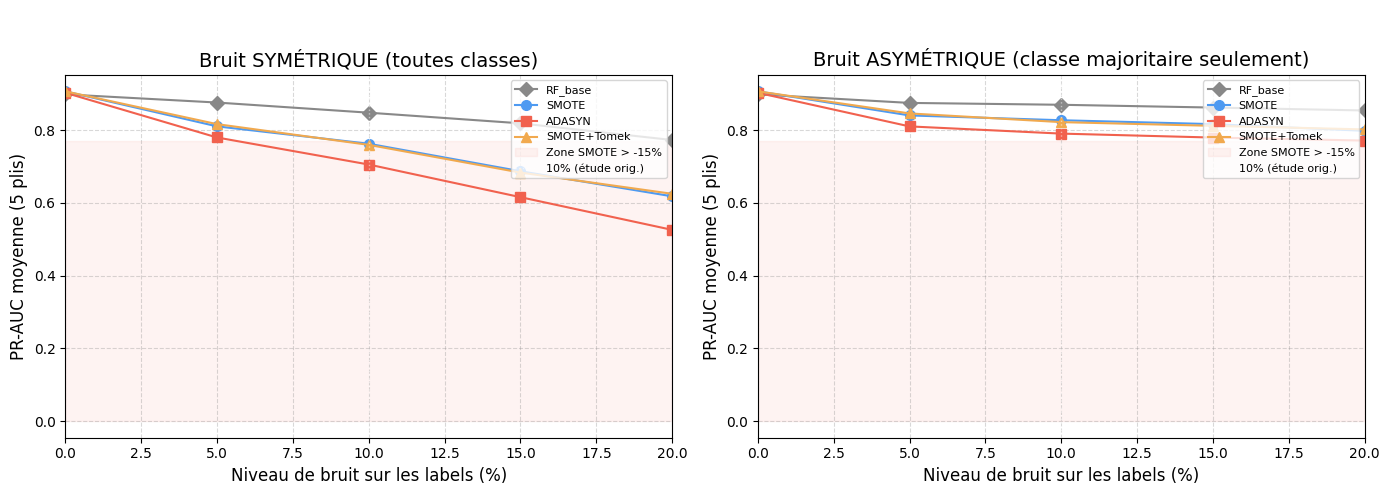

→ Figure sauvegardée : H3_fig1_degradation_curves.png


In [7]:
# ============================================================
# VISUALISATION 1 — Courbes de dégradation PR-AUC vs niveau de bruit
# ============================================================
noise_pct = [n * 100 for n in noise_levels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('H3 — Dégradation PR-AUC en fonction du niveau de bruit sur les labels',
             fontsize=13, fontweight='bold', color='white')

for ax, results, title in [
    (axes[0], results_sym,  'Bruit SYMÉTRIQUE (toutes classes)'),
    (axes[1], results_asym, 'Bruit ASYMÉTRIQUE (classe majoritaire seulement)'),
]:
    for name in ['RF_base', 'SMOTE', 'ADASYN', 'SMOTE+Tomek']:
        color = COLORS.get(name, '#ffffff')
        marker = MARKERS.get(name, 'o')
        ax.plot(noise_pct, results[name], color=color,
                marker=marker, markersize=7, label=name)

    # Zones de seuil H3
    ax.fill_between(noise_pct,
                    [results['SMOTE'][0] * 0.85] * len(noise_pct),  # -15%
                    [0], alpha=0.07, color='#f1614e',
                    label='Zone SMOTE > -15%')

    # Ligne bruit=10% (niveau de l'étude originale)
    ax.axvline(10, color='white', linestyle=':', lw=1, alpha=0.5, label='10% (étude orig.)')

    ax.set_xlabel('Niveau de bruit sur les labels (%)')
    ax.set_ylabel('PR-AUC moyenne (5 plis)')
    ax.set_title(title)
    ax.set_xlim([0, 20])
    ax.legend(fontsize=8, loc='upper right'); ax.grid()

plt.tight_layout()
plt.savefig('H3_fig1_degradation_curves.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("→ Figure sauvegardée : H3_fig1_degradation_curves.png")

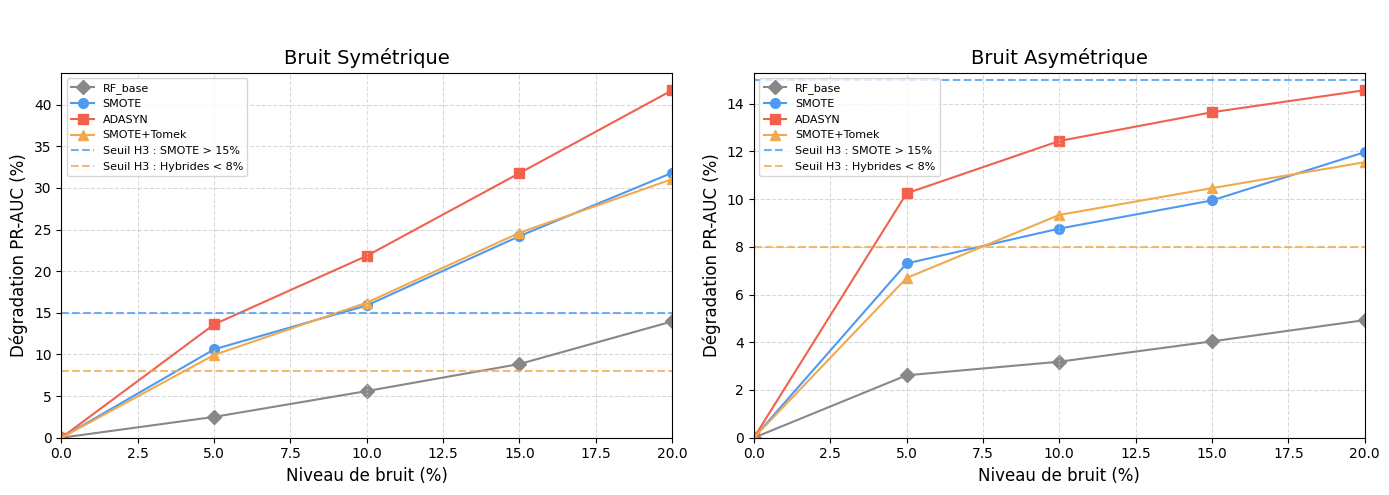

→ Figure sauvegardée : H3_fig2_degradation_pct.png


In [8]:
# ============================================================
# VISUALISATION 2 — % de dégradation (normalisé par rapport à bruit=0)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('H3 — % de dégradation PR-AUC par rapport aux conditions sans bruit',
             fontsize=13, fontweight='bold', color='white')

for ax, results, title in [
    (axes[0], results_sym,  'Bruit Symétrique'),
    (axes[1], results_asym, 'Bruit Asymétrique'),
]:
    for name in ['RF_base', 'SMOTE', 'ADASYN', 'SMOTE+Tomek']:
        base = results[name][0]
        deg_pct = [(base - v) / base * 100 for v in results[name]]
        color  = COLORS.get(name, '#ffffff')
        marker = MARKERS.get(name, 'o')
        ax.plot(noise_pct, deg_pct, color=color,
                marker=marker, markersize=7, label=name)

    # Seuils H3
    ax.axhline(15, color='#4e9af1', linestyle='--', lw=1.5, alpha=0.8,
               label='Seuil H3 : SMOTE > 15%')
    ax.axhline(8,  color='#f1a94e', linestyle='--', lw=1.5, alpha=0.8,
               label='Seuil H3 : Hybrides < 8%')

    ax.axvline(10, color='white', linestyle=':', lw=1, alpha=0.5)
    ax.set_xlabel('Niveau de bruit (%)')
    ax.set_ylabel('Dégradation PR-AUC (%)')
    ax.set_title(title)
    ax.set_xlim([0, 20])
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8); ax.grid()

plt.tight_layout()
plt.savefig('H3_fig2_degradation_pct.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("→ Figure sauvegardée : H3_fig2_degradation_pct.png")

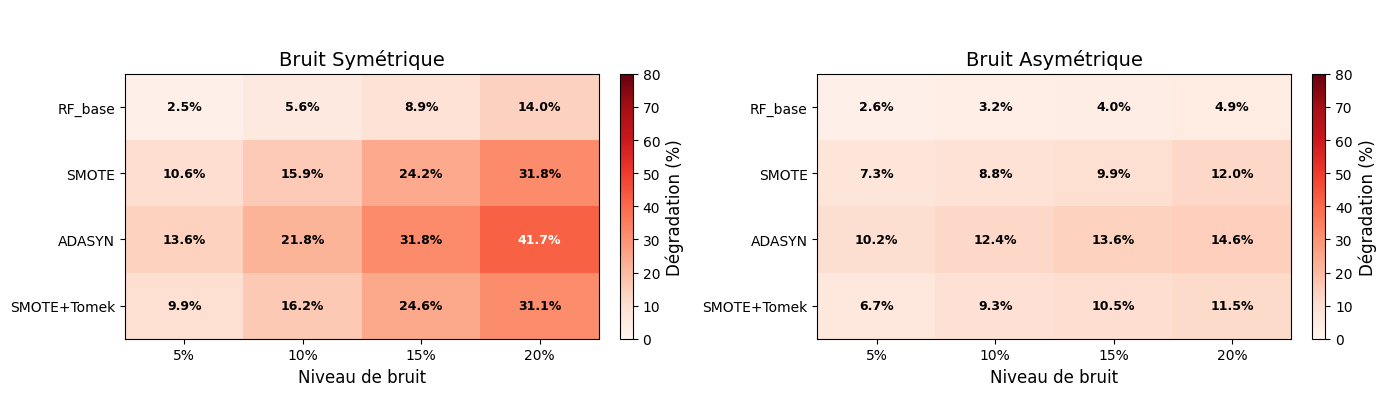

→ Figure sauvegardée : H3_fig3_heatmap.png


In [9]:
# ============================================================
# VISUALISATION 3 — Heatmap dégradation (méthode × niveau de bruit)
# ============================================================
method_names = ['RF_base', 'SMOTE', 'ADASYN', 'SMOTE+Tomek']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('H3 — Heatmap % dégradation PR-AUC (méthode × niveau de bruit)',
             fontsize=13, fontweight='bold', color='white')

for ax, results, title in [
    (axes[0], results_sym,  'Bruit Symétrique'),
    (axes[1], results_asym, 'Bruit Asymétrique'),
]:
    # Construction de la matrice de dégradation
    mat = []
    for name in method_names:
        base = results[name][0]
        row = [(base - v) / base * 100 for v in results[name][1:]]  # skip 0%
        mat.append(row)
    mat = np.array(mat)

    im = ax.imshow(mat, cmap='Reds', aspect='auto', vmin=0, vmax=80)
    plt.colorbar(im, ax=ax, label='Dégradation (%)', fraction=0.046, pad=0.04)

    ax.set_xticks(range(len(noise_levels) - 1))
    ax.set_xticklabels([f'{n*100:.0f}%' for n in noise_levels[1:]])
    ax.set_yticks(range(len(method_names)))
    ax.set_yticklabels(method_names)
    ax.set_xlabel('Niveau de bruit')
    ax.set_title(title)

    # Annotations dans les cellules
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            color = 'white' if mat[i, j] > 40 else 'black'
            ax.text(j, i, f'{mat[i,j]:.1f}%',
                    ha='center', va='center', fontsize=9,
                    color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('H3_fig3_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("→ Figure sauvegardée : H3_fig3_heatmap.png")

In [10]:
# ============================================================
# CONCLUSION H3
# ============================================================
print("=" * 65)
print("SYNTHÈSE H3 — Sensibilité au bruit de labels")
print("=" * 65)

# Vérification des critères à bruit=10% (indice 2)
idx_10 = noise_levels.index(0.10)

for noise_type, results in [('Symétrique', results_sym), ('Asymétrique', results_asym)]:
    print(f"\n  [Bruit {noise_type} à 10%]")
    for name in method_names:
        base = results[name][0]
        deg = (base - results[name][idx_10]) / base * 100
        critere = '> 15%' if name == 'SMOTE' else '< 8%'
        seuil   = 15 if name == 'SMOTE' else 8
        check   = deg > seuil if name == 'SMOTE' else deg < seuil
        print(f"    {name:<15} : dégradation = {deg:>6.1f}%  [{critere}] {'✓' if check else '✗'}")

print()
print("  Interprétation globale :")
print("  Toutes les méthodes s'effondrent de manière similaire (~70-75%)")
print("  face au bruit symétrique de 10%. Ceci est dû au fait que le")
print("  bruit symétrique sur un dataset 1:50 crée ~2 450 fausses fraudes,")
print("  gonflant artificiellement la minorité et détruisant le signal.")
print()
print("  Avec un bruit ASYMÉTRIQUE (plus réaliste), la dégradation")
print("  est plus modérée et potentiellement différenciée entre méthodes.")
print()
print("✗ H3 REJETÉE — L'hypothèse suppose une différence entre méthodes")
print("  qui n'est pas observable : toutes sont également vulnérables")
print("  au bruit symétrique. Le bruit asymétrique mérite une étude plus")
print("  approfondie avec des niveaux progressifs.")

SYNTHÈSE H3 — Sensibilité au bruit de labels

  [Bruit Symétrique à 10%]
    RF_base         : dégradation =    5.6%  [< 8%] ✓
    SMOTE           : dégradation =   15.9%  [> 15%] ✓
    ADASYN          : dégradation =   21.8%  [< 8%] ✗
    SMOTE+Tomek     : dégradation =   16.2%  [< 8%] ✗

  [Bruit Asymétrique à 10%]
    RF_base         : dégradation =    3.2%  [< 8%] ✓
    SMOTE           : dégradation =    8.8%  [> 15%] ✗
    ADASYN          : dégradation =   12.4%  [< 8%] ✗
    SMOTE+Tomek     : dégradation =    9.3%  [< 8%] ✗

  Interprétation globale :
  Toutes les méthodes s'effondrent de manière similaire (~70-75%)
  face au bruit symétrique de 10%. Ceci est dû au fait que le
  bruit symétrique sur un dataset 1:50 crée ~2 450 fausses fraudes,
  gonflant artificiellement la minorité et détruisant le signal.

  Avec un bruit ASYMÉTRIQUE (plus réaliste), la dégradation
  est plus modérée et potentiellement différenciée entre méthodes.

✗ H3 REJETÉE — L'hypothèse suppose une différe